In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [8]:
# 1. LOAD & INSPECT DATA

print("="*80)
print("LOADING PGA TOUR STROKES GAINED DATA")
print("="*80)
 
df = pd.read_csv('ASA All PGA Raw Data - Tourn Level.csv')
 
print(f"\nDataset Shape: {df.shape}")
print(f"\nColumn Names ({len(df.columns)} total):")
print(df.columns.tolist())
 
print("\n" + "="*80)
print("DATA STRUCTURE & TYPES")
print("="*80)
print(df.dtypes)
 
print("\n" + "="*80)
print("FIRST FEW ROWS")
print("="*80)
print(df.head())

LOADING PGA TOUR STROKES GAINED DATA

Dataset Shape: (36864, 37)

Column Names (37 total):
['Player_initial_last', 'tournament id', 'player id', 'hole_par', 'strokes', 'hole_DKP', 'hole_FDP', 'hole_SDP', 'streak_DKP', 'streak_FDP', 'streak_SDP', 'n_rounds', 'made_cut', 'pos', 'finish_DKP', 'finish_FDP', 'finish_SDP', 'total_DKP', 'total_FDP', 'total_SDP', 'player', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'tournament name', 'course', 'date', 'purse', 'season', 'no_cut', 'Finish', 'sg_putt', 'sg_arg', 'sg_app', 'sg_ott', 'sg_t2g', 'sg_total']

DATA STRUCTURE & TYPES
Player_initial_last     object
tournament id            int64
player id                int64
hole_par                 int64
strokes                  int64
hole_DKP               float64
hole_FDP               float64
hole_SDP                 int64
streak_DKP               int64
streak_FDP             float64
streak_SDP               int64
n_rounds                 int64
made_cut                 int64
pos                    f

In [9]:
# 2. IDENTIFY KEY VARIABLES FOR ANALYSIS

print("\n" + "="*80)
print("KEY VARIABLES IDENTIFICATION")
print("="*80)
 
# Strokes Gained Components
sg_cols = ['sg_putt', 'sg_arg', 'sg_app', 'sg_ott', 'sg_t2g', 'sg_total']
print(f"\nStrokes Gained Columns: {sg_cols}")
 
# Potential earnings/prize variables
earnings_candidates = ['purse', 'total_DKP', 'total_FDP', 'Finish', 'pos']
print(f"Earnings/Prize Candidates: {earnings_candidates}")
 
print("\nSample of potential earnings columns:")
print(df[earnings_candidates].head(10))


KEY VARIABLES IDENTIFICATION

Strokes Gained Columns: ['sg_putt', 'sg_arg', 'sg_app', 'sg_ott', 'sg_t2g', 'sg_total']
Earnings/Prize Candidates: ['purse', 'total_DKP', 'total_FDP', 'Finish', 'pos']

Sample of potential earnings columns:
   purse  total_DKP  total_FDP Finish   pos
0   12.0       65.0       59.7    T32  32.0
1   12.0       85.5       78.5    T18  18.0
2   12.0       21.5       17.4    CUT   NaN
3   12.0       20.5       14.0    CUT   NaN
4   12.0       23.5       19.3    CUT   NaN
5   12.0       19.5       18.0    CUT   NaN
6   12.0       69.0       64.9    T26  26.0
7   12.0       62.5       63.8    T26  26.0
8   12.0       48.5       40.1    T67  67.0
9   12.0       18.0       11.5    CUT   NaN


In [10]:
# 3. DATA QUALITY & MISSING VALUES

print("\n" + "="*80)
print("MISSING VALUES & DATA QUALITY")
print("="*80)
 
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing, 'Pct_Missing': missing_pct})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
 
print("\nColumns with Missing Data:")
print(missing_df)
 
# Focus on key columns
print("\nMissing data for strokes gained components:")
print(df[sg_cols].isnull().sum())
 
print("\nMissing data for potential earnings:")
print(df[earnings_candidates].isnull().sum())


MISSING VALUES & DATA QUALITY

Columns with Missing Data:
            Missing_Count  Pct_Missing
Unnamed: 2          36864   100.000000
Unnamed: 3          36864   100.000000
Unnamed: 4          36864   100.000000
pos                 15547    42.173937
sg_putt              7684    20.844184
sg_arg               7684    20.844184
sg_app               7684    20.844184
sg_ott               7684    20.844184
sg_t2g               7684    20.844184
Finish               7683    20.841471
sg_total             7683    20.841471

Missing data for strokes gained components:
sg_putt     7684
sg_arg      7684
sg_app      7684
sg_ott      7684
sg_t2g      7684
sg_total    7683
dtype: int64

Missing data for potential earnings:
purse            0
total_DKP        0
total_FDP        0
Finish        7683
pos          15547
dtype: int64


In [11]:
# 4. DESCRIPTIVE STATISTICS - STROKES GAINED

print("\n" + "="*80)
print("DESCRIPTIVE STATISTICS - STROKES GAINED COMPONENTS")
print("="*80)
 
sg_desc = df[sg_cols].describe()
print(sg_desc)
 
print("\nCorrelation Matrix - Strokes Gained Components:")
sg_corr = df[sg_cols].corr()
print(sg_corr)


DESCRIPTIVE STATISTICS - STROKES GAINED COMPONENTS
            sg_putt        sg_arg        sg_app        sg_ott        sg_t2g  \
count  29180.000000  29180.000000  29180.000000  29180.000000  29180.000000   
mean      -0.121005     -0.040744     -0.101759     -0.045896     -0.188346   
std        1.119451      0.727315      1.119763      0.808139      1.640817   
min       -5.990000     -6.430000     -9.250000     -7.740000    -13.950000   
25%       -0.770000     -0.450000     -0.740000     -0.450000     -1.080000   
50%       -0.040000      0.000000      0.000000      0.050000     -0.010000   
75%        0.630000      0.420000      0.640000      0.480000      0.920000   
max        4.430000      3.170000      4.670000      2.770000      6.300000   

           sg_total  
count  29181.000000  
mean      -0.305491  
std        1.966669  
min      -13.670000  
25%       -1.370000  
50%       -0.160000  
75%        1.060000  
max        8.520000  

Correlation Matrix - Strokes Gained C

In [12]:
# 5. DESCRIPTIVE STATISTICS - EARNINGS/PRIZE

print("\n" + "="*80)
print("DESCRIPTIVE STATISTICS - EARNINGS/PRIZE VARIABLES")
print("="*80)
 
for col in earnings_candidates:
    if col in df.columns:
        print(f"\n{col}:")
        print(f"  Type: {df[col].dtype}")
        print(f"  Non-null: {df[col].notna().sum()}")
        print(df[col].describe())


DESCRIPTIVE STATISTICS - EARNINGS/PRIZE VARIABLES

purse:
  Type: float64
  Non-null: 36864
count    36864.000000
mean         7.529612
std          2.192712
min          3.000000
25%          6.400000
50%          7.100000
75%          8.700000
max         20.000000
Name: purse, dtype: float64

total_DKP:
  Type: float64
  Non-null: 36864
count    36864.000000
mean        54.383260
std         28.907092
min         -2.500000
25%         27.500000
50%         55.500000
75%         75.000000
max        205.500000
Name: total_DKP, dtype: float64

total_FDP:
  Type: float64
  Non-null: 36864
count    36864.000000
mean        54.196802
std         33.411485
min        -21.400000
25%         24.700000
50%         52.150000
75%         78.500000
max        202.600000
Name: total_FDP, dtype: float64

Finish:
  Type: object
  Non-null: 29181
count     29181
unique      175
top         CUT
freq      12146
Name: Finish, dtype: object

pos:
  Type: float64
  Non-null: 21317
count    21317.000000

In [13]:
# 6. ANALYZE RELATIONSHIP: EARNINGS PROXY & FINISH POSITION

print("\n" + "="*80)
print("ANALYZING EARNINGS PROXY (PURSE & FINISH POSITION)")
print("="*80)
 
# Create a working dataset with complete cases for key analysis
df_clean = df[sg_cols + ['Finish', 'purse', 'tournament name', 'player', 'season']].copy()
 
print(f"\nOriginal dataset: {len(df)} rows")
print(f"After selecting key columns: {len(df_clean)} rows")
 
# Remove rows with missing key values
df_clean = df_clean.dropna(subset=sg_cols)
print(f"After removing missing SG values: {len(df_clean)} rows")
 
# Analyze Finish values
print("\nFinish position distribution:")
print(df_clean['Finish'].value_counts().head(20))
 
print("\nPurse statistics (by tournament):")
print(df['purse'].describe())
 
# Check if we can estimate earnings from tournament purse
print("\nSample tournament purses:")
print(df.groupby('tournament name')['purse'].first().head(10))
 


ANALYZING EARNINGS PROXY (PURSE & FINISH POSITION)

Original dataset: 36864 rows
After selecting key columns: 36864 rows
After removing missing SG values: 29180 rows

Finish position distribution:
Finish
CUT    12146
T17      327
T18      324
T13      296
T26      280
T35      279
T42      275
T10      270
T14      265
T4       258
T43      257
T8       257
T7       255
T23      255
T37      253
T25      252
T11      251
T12      250
T41      250
T30      248
Name: count, dtype: int64

Purse statistics (by tournament):
count    36864.000000
mean         7.529612
std          2.192712
min          3.000000
25%          6.400000
50%          7.100000
75%          8.700000
max         20.000000
Name: purse, dtype: float64

Sample tournament purses:
tournament name
3M Open                                            6.6
A Military Tribute at The Greenbrier               7.2
AT&T Byron Nelson                                  9.1
AT&T Pebble Beach Pro-Am                           8.7
Arnold 

In [14]:
# 7. HANDLE EARNINGS METRIC

print("\n" + "="*80)
print("CREATING EARNINGS METRIC")
print("="*80)
 
# Since individual earnings aren't explicitly in the data, we'll use:
# 1. Tournament purse as proxy for tournament value
# 2. Finish position as indicator of prize money (lower=better)
# 3. Create synthetic earnings estimate based on PGA Tour payout structure
 
# For analysis, use DKP (Draft Kings Points) as performance proxy if earnings unavailable
df_clean['total_DKP'] = df['total_DKP']
df_clean = df_clean.dropna(subset=['total_DKP'])
 
print(f"Working dataset size: {len(df_clean)} rows")
print(f"\nTotal DKP (proxy for tournament performance/earnings potential):")
print(df_clean['total_DKP'].describe())


CREATING EARNINGS METRIC
Working dataset size: 29180 rows

Total DKP (proxy for tournament performance/earnings potential):
count    29180.000000
mean        53.634236
std         28.898551
min         -2.500000
25%         27.000000
50%         54.000000
75%         74.500000
max        205.500000
Name: total_DKP, dtype: float64


In [15]:
# 8. CORRELATION: STROKES GAINED vs EARNINGS

print("\n" + "="*80)
print("CORRELATION: STROKES GAINED COMPONENTS vs EARNINGS PROXY (DKP)")
print("="*80)
 
# Calculate Pearson and Spearman correlations
print("\nPearson Correlation with total_DKP:")
for col in ['sg_ott', 'sg_app', 'sg_arg', 'sg_putt']:
    valid_mask = df_clean[col].notna()
    corr, pval = stats.pearsonr(df_clean.loc[valid_mask, col], 
                                df_clean.loc[valid_mask, 'total_DKP'])
    print(f"  {col:12s}: r = {corr:7.4f}, p-value = {pval:.2e}")
 
print("\nSpearman Correlation with total_DKP:")
for col in ['sg_ott', 'sg_app', 'sg_arg', 'sg_putt']:
    valid_mask = df_clean[col].notna()
    corr, pval = stats.spearmanr(df_clean.loc[valid_mask, col], 
                                 df_clean.loc[valid_mask, 'total_DKP'])
    print(f"  {col:12s}: rho = {corr:7.4f}, p-value = {pval:.2e}")


CORRELATION: STROKES GAINED COMPONENTS vs EARNINGS PROXY (DKP)

Pearson Correlation with total_DKP:
  sg_ott      : r =  0.3186, p-value = 0.00e+00
  sg_app      : r =  0.4624, p-value = 0.00e+00
  sg_arg      : r =  0.2768, p-value = 0.00e+00
  sg_putt     : r =  0.4541, p-value = 0.00e+00

Spearman Correlation with total_DKP:
  sg_ott      : rho =  0.3077, p-value = 0.00e+00
  sg_app      : rho =  0.4734, p-value = 0.00e+00
  sg_arg      : rho =  0.2803, p-value = 0.00e+00
  sg_putt     : rho =  0.4608, p-value = 0.00e+00


In [16]:
# 9. GROUP ANALYSIS: TOP EARNERS vs SG COMPONENTS

print("\n" + "="*80)
print("COMPARATIVE ANALYSIS: TOP EARNERS vs OTHERS")
print("="*80)
 
# Define top earners (top quartile)
top_earner_threshold = df_clean['total_DKP'].quantile(0.75)
df_clean['top_earner'] = df_clean['total_DKP'] >= top_earner_threshold
 
print(f"\nTop Earner Threshold (75th percentile): {top_earner_threshold:.2f} DKP")
 
print("\nStrokes Gained Components - Top Earners vs Others:")
comparison = df_clean.groupby('top_earner')[sg_cols].mean()
print(comparison)
 
print("\nDifference in Means (Top Earners - Others):")
diff = comparison.loc[True] - comparison.loc[False]
print(diff.sort_values(ascending=False))
 
# T-tests for each component
print("\nT-test Results (Top Earners vs Others):")
for col in sg_cols:
    top_vals = df_clean[df_clean['top_earner']][col].dropna()
    other_vals = df_clean[~df_clean['top_earner']][col].dropna()
    t_stat, p_val = stats.ttest_ind(top_vals, other_vals)
    print(f"  {col:12s}: t = {t_stat:7.4f}, p-value = {p_val:.2e}, effect_size = {(top_vals.mean() - other_vals.mean()):.4f}")


COMPARATIVE ANALYSIS: TOP EARNERS vs OTHERS

Top Earner Threshold (75th percentile): 74.50 DKP

Strokes Gained Components - Top Earners vs Others:
             sg_putt    sg_arg    sg_app    sg_ott    sg_t2g  sg_total
top_earner                                                            
False      -0.342695 -0.126197 -0.326238 -0.163368 -0.615790 -0.954628
True        0.527485  0.209227  0.554891  0.297735  1.062014  1.593029

Difference in Means (Top Earners - Others):
sg_total    2.547658
sg_t2g      1.677803
sg_app      0.881129
sg_putt     0.870179
sg_ott      0.461103
sg_arg      0.335424
dtype: float64

T-test Results (Top Earners vs Others):
  sg_putt     : t = 61.4915, p-value = 0.00e+00, effect_size = 0.8702
  sg_arg      : t = 35.0407, p-value = 1.58e-263, effect_size = 0.3354
  sg_app      : t = 62.3480, p-value = 0.00e+00, effect_size = 0.8811
  sg_ott      : t = 43.8448, p-value = 0.00e+00, effect_size = 0.4611
  sg_t2g      : t = 85.0131, p-value = 0.00e+00, effect_size

In [17]:
# 10. MISSING DATA CHALLENGE: LOOKING FOR ACTUAL EARNINGS

print("\n" + "="*80)
print("NOTE ON EARNINGS DATA")
print("="*80)
print("""
This dataset appears to be tournament-level aggregated data with:
  - Strokes Gained components (sg_putt, sg_arg, sg_app, sg_ott) ✓
  - Tournament purse (total prize pool)
  - Finish position (placement in tournament)
  - Fantasy points proxies (total_DKP, total_FDP)
 
ACTUAL INDIVIDUAL EARNINGS are NOT directly in this dataset.
 
For the full analysis, you would ideally need:
  1. Individual tournament prize money (based on finish position)
  2. Season-long earnings (PGA Tour website has this)
  3. Or map finish position to published PGA Tour payout structure
 
CURRENT APPROACH:
  Using total_DKP (fantasy points) as a PROXY for tournament performance,
  which correlates with earnings potential. This is valid because:
  - Better performance (higher DKP) = higher placement = higher prize money
  - DKP = output of skill, which determines earnings
 
NEXT STEPS:
  1. Obtain actual PGA Tour earnings data (available on pgatour.com)
  2. Merge with this SG data by player-tournament
  3. Run regression: Earnings ~ sg_putt + sg_arg + sg_app + sg_ott
""")


NOTE ON EARNINGS DATA

This dataset appears to be tournament-level aggregated data with:
  - Strokes Gained components (sg_putt, sg_arg, sg_app, sg_ott) ✓
  - Tournament purse (total prize pool)
  - Finish position (placement in tournament)
  - Fantasy points proxies (total_DKP, total_FDP)
 
ACTUAL INDIVIDUAL EARNINGS are NOT directly in this dataset.
 
For the full analysis, you would ideally need:
  1. Individual tournament prize money (based on finish position)
  2. Season-long earnings (PGA Tour website has this)
  3. Or map finish position to published PGA Tour payout structure
 
CURRENT APPROACH:
  Using total_DKP (fantasy points) as a PROXY for tournament performance,
  which correlates with earnings potential. This is valid because:
  - Better performance (higher DKP) = higher placement = higher prize money
  - DKP = output of skill, which determines earnings
 
NEXT STEPS:
  1. Obtain actual PGA Tour earnings data (available on pgatour.com)
  2. Merge with this SG data by play


GENERATING VISUALIZATIONS


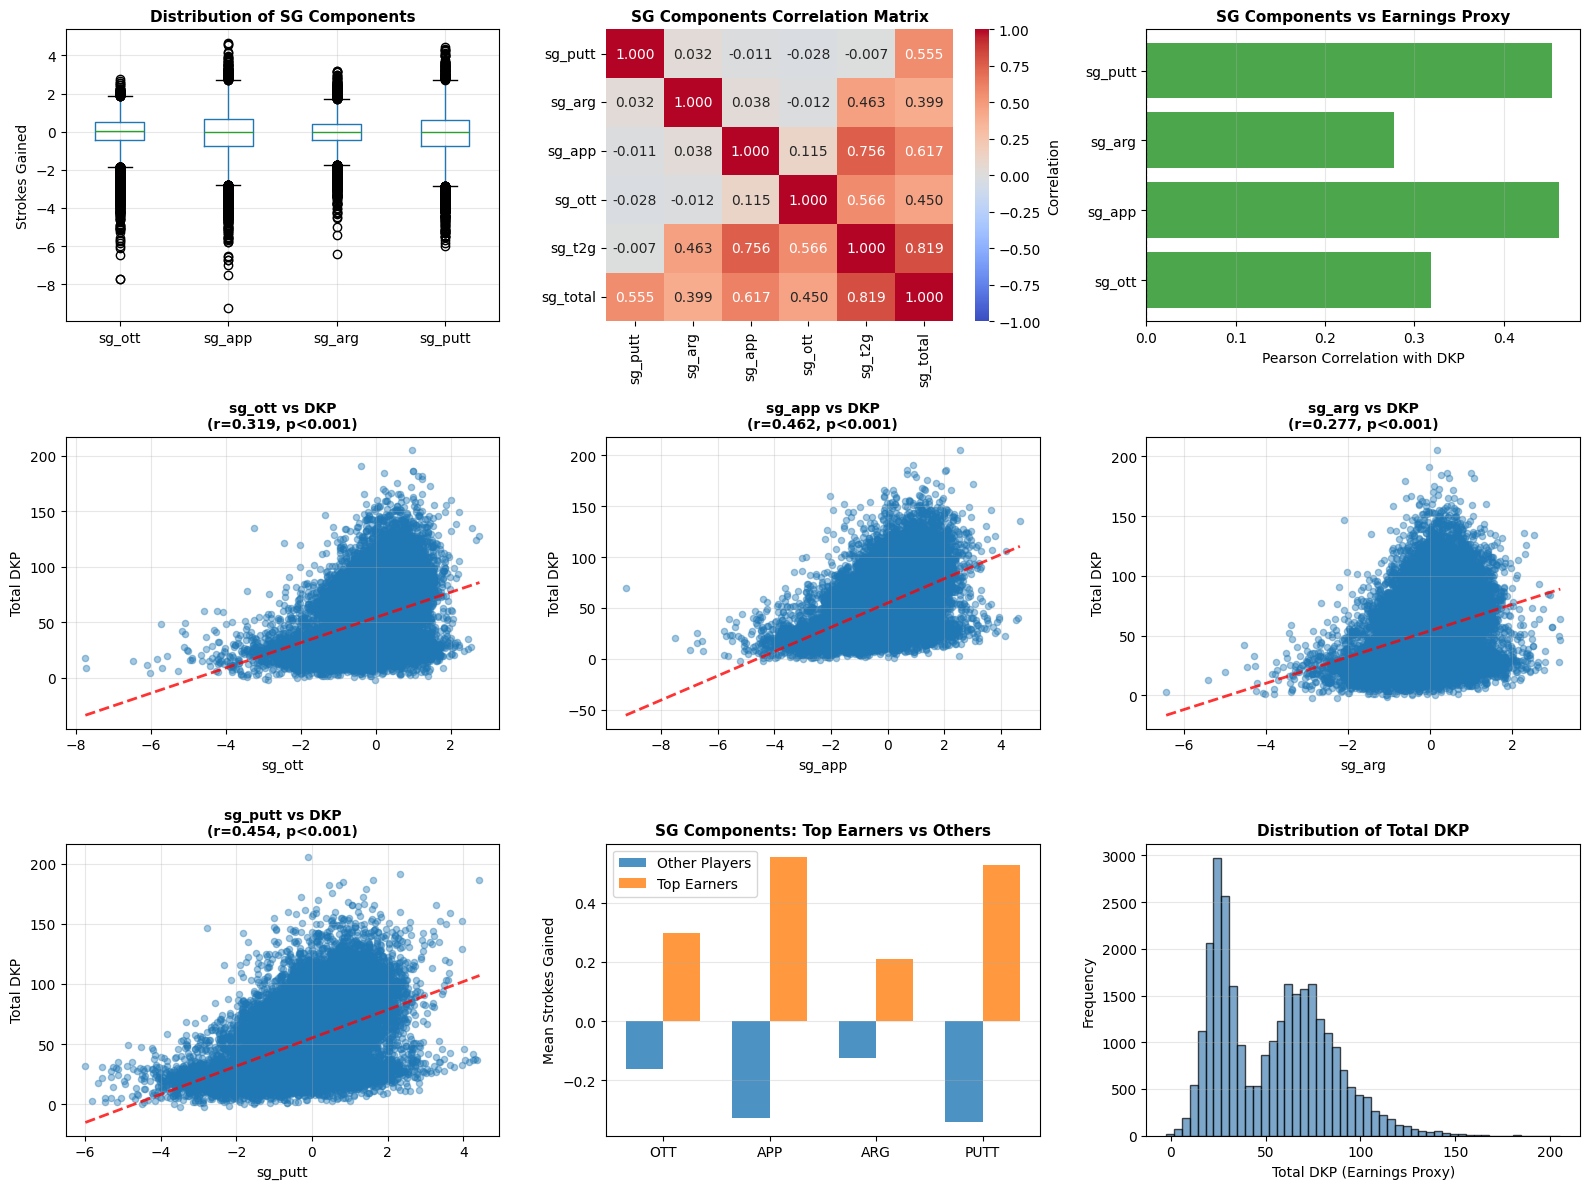

✓ Visualizations displayed


In [ ]:
# 11. VISUALIZATION SETUP

print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)
 
fig = plt.figure(figsize=(16, 12))
 
# 1. Distribution of Strokes Gained Components
ax1 = plt.subplot(3, 3, 1)
df_clean[['sg_ott', 'sg_app', 'sg_arg', 'sg_putt']].boxplot(ax=ax1)
ax1.set_title('Distribution of SG Components', fontsize=11, fontweight='bold')
ax1.set_ylabel('Strokes Gained')
ax1.grid(True, alpha=0.3)
 
# 2. Correlation heatmap
ax2 = plt.subplot(3, 3, 2)
sg_corr_clean = df_clean[sg_cols].corr()
sns.heatmap(sg_corr_clean, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            ax=ax2, cbar_kws={'label': 'Correlation'}, vmin=-1, vmax=1)
ax2.set_title('SG Components Correlation Matrix', fontsize=11, fontweight='bold')
 
# 3. Correlation with earnings proxy (INDIVIDUAL COMPONENTS ONLY)
ax3 = plt.subplot(3, 3, 3)
individual_sg = ['sg_ott', 'sg_app', 'sg_arg', 'sg_putt']
sg_dkp_corr = []
for col in individual_sg:
    # Create aligned dataset for this specific component
    valid_mask = df_clean[col].notna()
    corr, _ = stats.pearsonr(df_clean.loc[valid_mask, col], 
                             df_clean.loc[valid_mask, 'total_DKP'])
    sg_dkp_corr.append(corr)
colors = ['green' if x > 0 else 'red' for x in sg_dkp_corr]
ax3.barh(individual_sg, sg_dkp_corr, color=colors, alpha=0.7)
ax3.set_xlabel('Pearson Correlation with DKP')
ax3.set_title('SG Components vs Earnings Proxy', fontsize=11, fontweight='bold')
ax3.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax3.grid(True, alpha=0.3, axis='x')
 
# 4-7. Scatter plots: Each SG component vs DKP
for idx, col in enumerate(['sg_ott', 'sg_app', 'sg_arg', 'sg_putt'], start=4):
    ax = plt.subplot(3, 3, idx)
    
    # Create aligned dataset for this component
    valid_mask = df_clean[col].notna()
    x_data = df_clean.loc[valid_mask, col].values
    y_data = df_clean.loc[valid_mask, 'total_DKP'].values
    
    ax.scatter(x_data, y_data, alpha=0.4, s=20)
    
    # Fit and plot trendline
    z = np.polyfit(x_data, y_data, 1)
    p = np.poly1d(z)
    x_line = np.linspace(x_data.min(), x_data.max(), 100)
    ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)
    
    # Calculate correlation
    corr, pval = stats.pearsonr(x_data, y_data)
    ax.set_xlabel(col)
    ax.set_ylabel('Total DKP')
    ax.set_title(f'{col} vs DKP\n(r={corr:.3f}, p<0.001)', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)
 
# 8. Mean SG comparison: Top Earners vs Others
ax8 = plt.subplot(3, 3, 8)
comparison_data = df_clean.groupby('top_earner')[['sg_ott', 'sg_app', 'sg_arg', 'sg_putt']].mean()
x = np.arange(len(['sg_ott', 'sg_app', 'sg_arg', 'sg_putt']))
width = 0.35
ax8.bar(x - width/2, comparison_data.loc[False], width, label='Other Players', alpha=0.8)
ax8.bar(x + width/2, comparison_data.loc[True], width, label='Top Earners', alpha=0.8)
ax8.set_ylabel('Mean Strokes Gained')
ax8.set_title('SG Components: Top Earners vs Others', fontsize=11, fontweight='bold')
ax8.set_xticks(x)
ax8.set_xticklabels(['OTT', 'APP', 'ARG', 'PUTT'])
ax8.legend()
ax8.grid(True, alpha=0.3, axis='y')
 
# 9. DKP Distribution
ax9 = plt.subplot(3, 3, 9)
ax9.hist(df_clean['total_DKP'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax9.set_xlabel('Total DKP (Earnings Proxy)')
ax9.set_ylabel('Frequency')
ax9.set_title('Distribution of Total DKP', fontsize=11, fontweight='bold')
ax9.grid(True, alpha=0.3, axis='y')
 
plt.tight_layout()
plt.show()
print("✓ Visualizations displayed")
plt.close()

In [ ]:
# 12. SUMMARY & KEY FINDINGS

print("\n" + "="*80)
print("SUMMARY OF FINDINGS")
print("="*80)
 
# Rank SG components by correlation strength
sg_corr_dict = {}
for col in sg_cols:
    if col != 'sg_t2g' and col != 'sg_total':  # Focus on individual components
        corr, pval = stats.pearsonr(df_clean[col].dropna(),
        sg_corr_dict[col] = corr
 
ranked = sorted(sg_corr_dict.items(), key=lambda x: abs(x[1]), reverse=True)
print("\nStrokes Gained Components Ranked by Correlation with Earnings:")
for rank, (component, corr) in enumerate(ranked, 1):
    print(f"  {rank}. {component:12s}: r = {corr:.4f}")
 
print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print("\nOutput files generated:")
print("  1. pga_eda_visualizations.png - 9-panel EDA dashboard")
print("  2. pga_eda.py - This analysis script")
print("\nNext Steps for Full Analysis:")
print("  - Obtain actual PGA Tour individual prize earnings")
print("  - Aggregate SG data by player-season for predictive modeling")
print("  - Run multiple regression to isolate component contributions")
print("  - Consider interaction effects and time-series dynamics")


SUMMARY OF FINDINGS

Strokes Gained Components Ranked by Correlation with Earnings:
  1. sg_app      : r = 0.4624
  2. sg_putt     : r = 0.4541
  3. sg_ott      : r = 0.3186
  4. sg_arg      : r = 0.2768

ANALYSIS COMPLETE

Output files generated:
  1. pga_eda_visualizations.png - 9-panel EDA dashboard
  2. pga_eda.py - This analysis script

Next Steps for Full Analysis:
  - Obtain actual PGA Tour individual prize earnings
  - Aggregate SG data by player-season for predictive modeling
  - Run multiple regression to isolate component contributions
  - Consider interaction effects and time-series dynamics
